In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [8]:

df = pd.read_csv("model_dataset.csv")     

y = df["readmitted_30d"]     #target variable


#____________________________ REMOVE IDENTIFIERS ________________________


remove_columns = [
    "readmitted_30d",
    "subject_id",
    "hadm_id",
    "next_admission"
]

remove_columns = [
    c for c in remove_columns
    if c in df.columns]

X = df.drop(columns=remove_columns)

In [9]:

# _________________________________TRAIN TEST SPLIT ___________________________


X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )
)

In [10]:

# _____________________________COLUMN TYPES _______________________________


numeric_columns = (
    X.select_dtypes(include="number")
    .columns
)

categorical_columns = (
    X.select_dtypes(exclude="number")
    .columns
)

In [11]:

#_______________________________ PREPROCESSOR _____________________________


preprocessor = ColumnTransformer(
    [
        (
            "num",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]
            ),
            numeric_columns
        ),
        (
            "cat",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        )
                    )
                ]
            ),
            categorical_columns
        )
    ]
)


In [12]:

# _______________________ MODEL __________________________________


model = Pipeline(
    [
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


In [13]:

# ______________________________TRAIN ________________________


model.fit(
    X_train,
    y_train
)

# __________________________PREDICT __________________________________


predictions = model.predict(
    X_test
)

probabilities = (
    model.predict_proba(X_test)[:, 1]
)


In [14]:

# ___________________________METRICS ____________________________


metrics = pd.DataFrame(
    [
        {
            "accuracy":
                accuracy_score(
                    y_test,
                    predictions
                ),

            "precision":
                precision_score(
                    y_test,
                    predictions
                ),

            "recall":
                recall_score(
                    y_test,
                    predictions
                ),

            "f1":
                f1_score(
                    y_test,
                    predictions
                ),

            "roc_auc":
                roc_auc_score(
                    y_test,
                    probabilities
                )
        }
    ]
)

metrics.to_csv(
    "model1_metrics.csv",
    index=False
)


In [15]:
# __________________________SAVE PREDICTIONS___________________________


prediction_df = pd.DataFrame(
    {
        "actual": y_test,
        "prediction": predictions,
        "probability": probabilities
    }
)

prediction_df.to_csv(
    "model1_predictions.csv",
    index=False
)

print(metrics)


   accuracy  precision  recall        f1   roc_auc
0  0.983169   0.923528     1.0  0.960244  0.999861


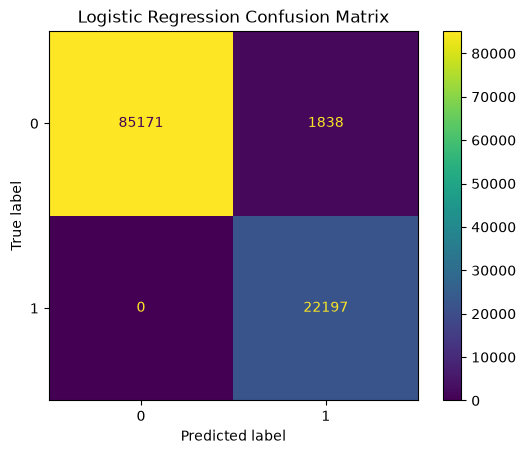

In [16]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.title("Logistic Regression Confusion Matrix")
plt.savefig("confusion_matrix_model1.png")
plt.show()